In [14]:
import math
import random
import numpy as np
import gymnasium as gym

from time import sleep
from collections import deque
from itertools import count

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from importnb import Notebook
with Notebook():
    from LabLatencyModel import LatencyModel
    from LabCacheEngine import CacheEngineEnv
    from LabUserTileRequest import UserTileRequestEvents
    from LabEnvWrapper import EnvWrapper

In [15]:
# Check PyTorch GPU availability and basic operation
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Using device: {torch.cuda.get_device_name(torch.cuda.current_device())}")
    x = torch.randn(2, 2, device="cuda")
    y = torch.randn(2, 2, device="cuda")
    print("Sample CUDA tensor sum:\n", (x + y))
else:
    print("GPU not detected; running on CPU.")

CUDA available: True
Using device: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Sample CUDA tensor sum:
 tensor([[ 1.6707,  1.2705],
        [ 0.5714, -0.6790]], device='cuda:0')


In [ ]:
class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        # state shape: (seq_len, input_size)
        self.memory.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

class LSTM_DQN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(LSTM_DQN, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM Layer: Takes sequence of viewports
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        
        # Fully Connected Layer: Maps LSTM output to Q-values (one per tile index)
        self.fc = nn.Linear(hidden_size, output_size)

        self.sigmoid = nn.Sigmoid() # Squish output between 0 and 1
        
    def forward(self, x):
        # x: (Batch, Seq_Len, Features)
        lstm_out, _ = self.lstm(x)
        
        # We take the last time step's output
        last_step_out = lstm_out[:, -1, :]
        
        # Produce logits then probabilities
        logits = self.fc(last_step_out)
        probs = self.sigmoid(logits)
        return probs, logits


# --- New Probability Agent ---
class ProbabilityAgent:
    def __init__(
        self, 
        n_tiles, 
        seq_len, 
        threshold=0.5, 
        learning_rate=1e-3,
        batch_size=32,
        capacity=10000,
        epsilon_start=1.0,
        epsilon_min=0.05,
        epsilon_decay=0.995
    ):
        self.n_tiles = n_tiles
        self.seq_len = seq_len
        self.epsilon = epsilon_start
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.threshold = threshold
        
        # Replay Memory
        self.memory = deque(maxlen=capacity)
        self.batch_size = batch_size
        
        # Network
        self.model = LSTM_DQN(n_tiles, 128, n_tiles)
        self.optimizer = optim.Adam(
            self.model.parameters(), 
            lr=learning_rate
        )
        self.criterion = nn.BCELoss() # Binary Cross Entropy Loss
        
    def predict_mask(self, state_seq):
        """
        Input: state_seq (Seq_Len, n_tiles)
        Output: Binary mask (n_tiles,) based on threshold
        """
        # Convert to tensor (Batch=1)
        state_tensor = torch.FloatTensor(state_seq).unsqueeze(0)
        
        with torch.no_grad():
            probs, _ = self.model(state_tensor) # Shape: (1, n_tiles)
            
        # Convert to numpy and apply threshold
        probs_np = probs.squeeze(0).numpy()
        
        # Action: 1 if prob > threshold, else 0
        mask = (probs_np > self.threshold).astype(int)
        return mask
    
    def remember(self, state, actual_future_mask):
        """
        Store the state and the ACTUAL mask that happened (Ground Truth).
        We don't need 'reward' for training in this supervised setup, 
        because 'perfect prediction' implies 'max reward'.
        """
        self.memory.append((state, actual_future_mask))
        
    def train_step(self):
        if len(self.memory) < self.batch_size:
            return 0.0
        
        batch = random.sample(self.memory, self.batch_size)
        states, targets = zip(*batch)
        
        # Convert to tensors
        states_tensor = torch.FloatTensor(np.array(states))   # (B, Seq, Input)
        targets_tensor = torch.FloatTensor(np.array(targets)) # (B, Input)
        
        # Forward pass
        probs, _ = self.model(states_tensor)  # (B, Input)
        
        # Compute loss
        loss = self.criterion(probs, targets_tensor)
        
        # Backpropagation
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        return loss.item()
    
    def update_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

IndentationError: expected an indented block after class definition on line 46 (3877653541.py, line 47)

In [ ]:
if __name__ == "__main__":
    n_episodes = 200
    n_users = 100
    step_size = 5.0
    arrival_rate = 5.0  # users per second
    max_users_capacity = n_users
    alpha = 1.0
    n_videos = 100
    n_gops = 60
    n_layers = 2
    n = 4
    n_tiles = n * n
    max_capacity = 100e6  # 100 MB

    # Hyperparameters for RL
    epsilon_start = 1.0
    epsilon_min = 0.05
    epsilon_decay = 0.995
    gamma = 0.99
    learning_rate = 1e-3
    batch_size = 64
    capacity = 10000
    seq_len = 5  # LSTM sequence length (history window)
    caching_threshold = 0.4 # If P(tile) > 40%, cache it

    # CPT parameters
    theta = 0.5
    lam = 3.7183

    # Initialize User Environment
    users_env = UserTileRequestEvents(
        n_users=n_users,
        n_videos=n_videos,
        n_gops=n_gops,
        n_layers=n_layers,
        n_tiles=n_tiles,
        n=n,
        users_viewport_tiles=None,
        requested_videos=None,
        users_arrivals=None,
        arrival_rate=arrival_rate
    )

    cache_env = CacheEngineEnv(
        n_users=n_users,
        n_videos=n_videos,
        n_layers=n_layers,
        n_tiles=n_tiles,
        n_gops=n_gops,
        cache_capacity=max_capacity,
    )

    # Create latency model (replace numbers with your real config)
    P = 1; max_U = n_users
    lat_model = LatencyModel(
        P=P, 
        max_U=max_U,
        R_M_D=80e6,   # 640 Mbps -> 80e6 B/s 
        R_C_M=1.25e9, # 10 Gbps -> 1.25e9 B/s
        mu=2e7, 
        eta=2e5,
        B_pu_matrix=np.full((P, max_U), 40e6, dtype=float),       # 320 Mbps -> 40e6 B/s
        gamma_pu_matrix=np.full((P, max_U), 5.0, dtype=float),    # SNRs
        rhoT_p=[0.2], 
        lambda_p=[0.05],
        du_fixed_delay=0.001,    # 1 ms
        mec_fixed_delay=0.005,   # 5 ms
        cloud_fixed_delay=0.05   # 50 ms
    )

    env = EnvWrapper(
        n=n,
        n_layers=n_layers,
        users_env=users_env, 
        cache_env=cache_env, 
        latency_model=lat_model,
        theta=theta,
        lam=lam
    )

    print(
        f"Experiment ===================\n"
        f"Total users: {n_users}\n"
        f"Cache capacity: {max_capacity}MB\n"
        f"Video matrix: {n_videos}x{n_layers}x{n*n}\n"
        f"==============================\n"
    )
    
    agent = ProbabilityAgent(
        n_tiles=n_tiles, 
        seq_len=seq_len, 
        threshold=caching_threshold,
        learning_rate=learning_rate,
        batch_size=batch_size,
        capacity=capacity,
        epsilon_start=epsilon_start,
        epsilon_min=epsilon_min,
        epsilon_decay=epsilon_decay
    )

    results = []
    scores = []
    for ep in range(n_episodes):

        obs, info = env.reset()
        requested_videos = info['requested_videos']
        viewport_tiles = info['viewport_tiles']
        users_arrivals = info['users_arrivals'] 
        
        # User State History: Dictionary to track last 'seq_len' viewports per user
        # Initialize with zeros
        next_user_id = 0
        user_histories = {
            u: deque(
                [np.zeros(n*n) for _ in range(seq_len)], maxlen=seq_len
            ) for u in range(max_users_capacity)
        }

        cache_hits = 0
        cache_misses = 0
        total_reward = 0.0

        for step in count():

            # --- AGENT ACTIONS ---
            actions = []
            user_action_indices = {} # Store discrete action (center tile) for training
            
            active_users = []
            for u in range(len(users_arrivals)):
                if step >= users_arrivals[u] and step < users_arrivals[u] + n_gops:
                    active_users.append(u)

            for u in active_users:
                # Construct state from history
                cur_state_seq = np.array(user_histories[u]) # Shape (seq_len, 16)
                
                # Agent chooses center tile
                center_tile_idx, q_values = agent.select_action(cur_state_seq)
                user_action_indices[u] = center_tile_idx

                print(f"Q-values: {q_values}")
                # Convert center tile to mask for the Env
                predicted_mask = index_to_fov_mask(center_idx=center_tile_idx, n=n)
                
                # print(f"Step {step+1}, User {u}, center_tile_idx: \n")
                # print(f"{cur_state_seq}")

                # print(f"Step {step+1}, User {u}, Center Tile: {center_tile_idx}")
                # print(f"Predicted Mask ({n}x{n}):")
                # print(predicted_mask.reshape(n, n))

                actions.append({
                    'user': u,
                    'gop': step - users_arrivals[u],
                    'video': requested_videos[u],
                    'tiles': predicted_mask
                })
            
            # print(f"Episode {ep+1}, Step {step+1}, Active Users: {len(active_users)}")
            # print(f"Actions taken for users: {[a['user'] for a in actions]}")

            # --- STEP ENV ---
            obs, rewards, done, info = env.step(actions)

            total_reward += float(rewards)
            cache_hits += info["cache_hits"]
            cache_misses += info["cache_misses"]

            # --- TRAINING / HISTORY UPDATE ---
            step_reward = float(rewards) / max(1, len(active_users))
            
            for u in active_users:
                start_time = users_arrivals[u]
                local_step = step - start_time
                
                state_seq = np.array(user_histories[u])
                
                # Get the actual viewport mask for this step (Ground Truth)
                actual_mask = np.zeros(n*n)
                for tile in viewport_tiles[u][local_step]:
                    tx, ty = tile
                    if 0 <= tx < n and 0 <= ty < n:
                        actual_mask[ty * n + tx] = 1
                
                # Update history (Next State)
                user_histories[u].append(actual_mask)
                next_state_seq = np.array(user_histories[u])
                
                # Store in Replay Buffer
                # We store the experience: (State, Action_Index, Reward, Next_State, Done)
                dones = (local_step == n_gops - 1)
                agent.memory.push(
                    state_seq, 
                    user_action_indices[u], 
                    step_reward, 
                    next_state_seq, 
                    dones
                )
            
            # Train the agent (once per step, or multiple times)
            agent.train_step()

            # print(
            #     f"Step {step} - "
            #     f"Reward: {rewards:.4f} - "
            #     f"Cache Hits: {info['cache_hits']} - "
            #     f"Cache Misses: {info['cache_misses']}"
            # )

            # print(
            #     f"Cache Utilization: {info['cache_utilization']:.2%} - "
            #     f"Items in Cache: {info['cache_num_items']} - "
            #     f"Final Capacity: {info['cache_current_capacity']/1e6:.2f}/{info['cache_total_capacity']/1e6:.1f} MB"
            # )

            if done:
                break
            
        # Update Target Network and Decay Epsilon
        if ep % 5 == 0:
            agent.update_target_network()
            
        agent.update_epsilon()

        print(
            f"Episode {ep+1}/{n_episodes}, "
            f"Total Reward: {total_reward:.4f}, "
            f"cache_hits: {cache_hits}, "
            f"cache_misses: {cache_misses}, "
            f"Epsilon: {agent.epsilon:.4f}"
        )

        scores.append(total_reward)

        results.append({
            "episode": ep,
            "total_reward": total_reward,
            "cache_hits": cache_hits,
            "cache_misses": cache_misses,
        })

Experiment ===================
Total users: 100
Cache capacity: 100000000.0MB
Video matrix: 100x2x16

Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: None
Q-values: Non

KeyboardInterrupt: 

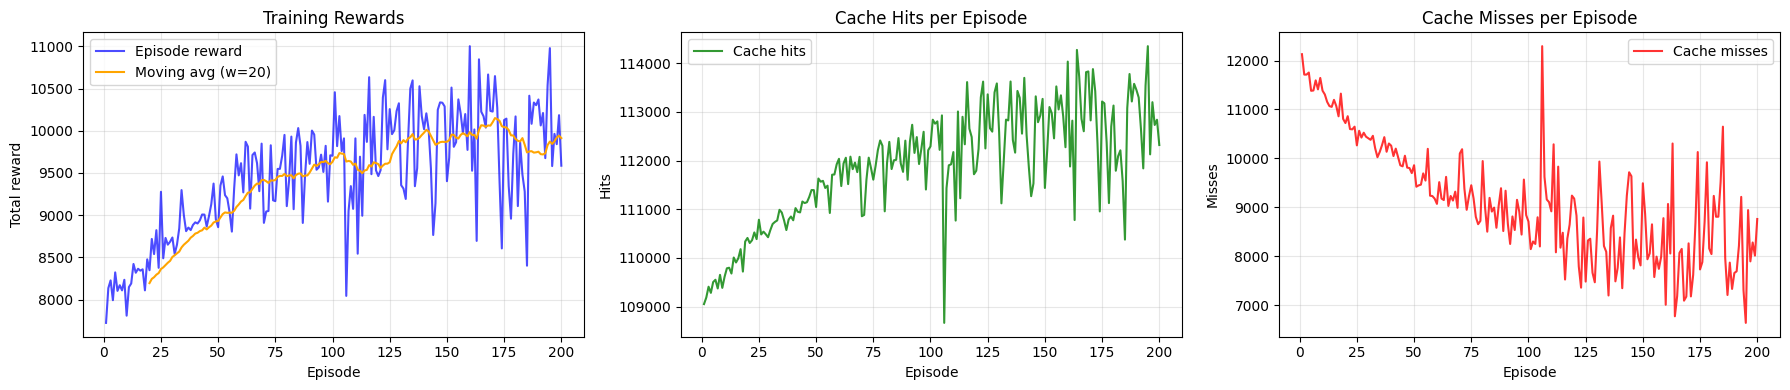

In [ ]:
# Combined plots: rewards (with moving average), cache hits, cache misses
import matplotlib.pyplot as plt

episodes = range(1, len(scores) + 1)
cache_hits_series = [r["cache_hits"] for r in results]
cache_misses_series = [r["cache_misses"] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)

# Rewards with moving average
axes[0].plot(episodes, scores, label="Episode reward", alpha=0.7, color="blue")
w = max(1, min(20, len(scores) // 10))
if w > 1:
    ma = [sum(scores[i - w:i]) / w for i in range(w, len(scores) + 1)]
    axes[0].plot(range(w, len(scores) + 1), ma, label=f"Moving avg (w={w})", color="orange")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total reward")
axes[0].set_title("Training Rewards")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Cache hits
axes[1].plot(episodes, cache_hits_series, label="Cache hits", color="green", alpha=0.8)
axes[1].set_title("Cache Hits per Episode")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Hits")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Cache misses
axes[2].plot(episodes, cache_misses_series, label="Cache misses", color="red", alpha=0.8)
axes[2].set_title("Cache Misses per Episode")
axes[2].set_xlabel("Episode")
axes[2].set_ylabel("Misses")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()